In [17]:
import joblib
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [18]:
df=pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [19]:
df['TotalCharges']=pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)
df=df.dropna()
df.drop(columns='customerID',inplace=True)
X=df.drop('Churn',axis=1)
y=df['Churn']

y=y.map({
    'No':0,
    "Yes":1
})
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
xgb_pipeline=joblib.load(
    "../models/xgboost.pkl"
)

In [8]:
xgb_model=xgb_pipeline.named_steps['model']

In [9]:
feature_names=(
    xgb_pipeline
    .named_steps['preprocessor']
    .get_feature_names_out()
)

In [10]:
importance_df=pd.DataFrame({
    "Feature":feature_names,
    "Importance":xgb_model.feature_importances_
})
importance_df=importance_df.sort_values(
    "Importance",

    ascending=False
)

In [12]:
top20=importance_df.head(20)
top20

,Feature,Importance
32,cat__Contract_Month-to-month,0.485636
12,cat__InternetService_Fiber optic,0.078609
14,cat__OnlineSecurity_No,0.043978
23,cat__TechSupport_No,0.039615
11,cat__InternetService_DSL,0.025554
6836,num__tenure,0.020568
34,cat__Contract_Two year,0.019199
33,cat__Contract_One year,0.013814
39,cat__PaymentMethod_Electronic check,0.012552
6837,num__MonthlyCharges,0.012354


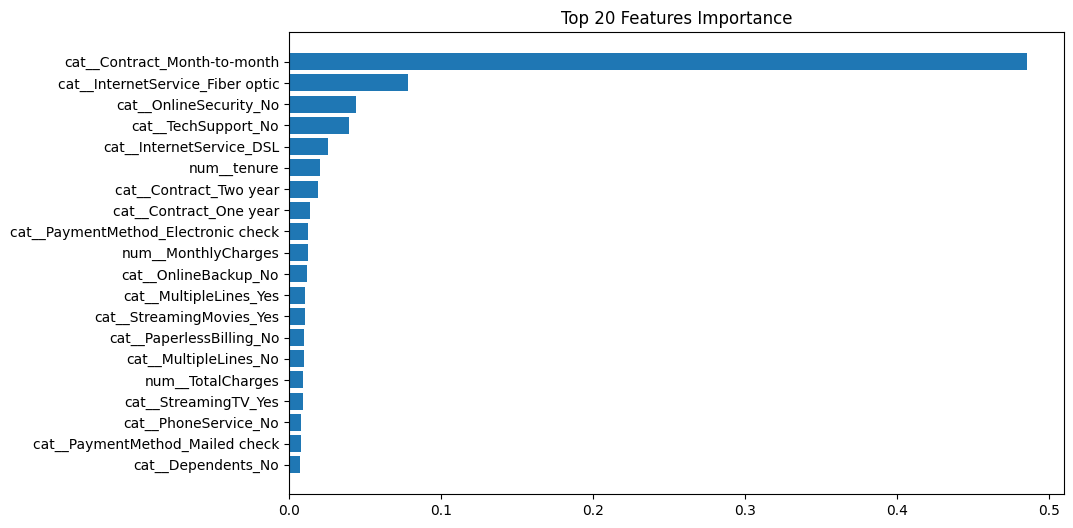

In [13]:
plt.figure(figsize=(10,6))
plt.barh(
    top20['Feature'],
    top20['Importance']
)
plt.gca().invert_yaxis()
plt.title("Top 20 Features Importance")
plt.show()

In [15]:
preprocessor=xgb_pipeline.named_steps['preprocessor']


In [20]:
X_test_transformed=preprocessor.transform(X_test)

In [21]:
explainer=shap.TreeExplainer(xgb_model)

In [22]:
shap_values=explainer.shap_values(
    X_test_transformed
)

In [25]:
feature_names = preprocessor.get_feature_names_out()
X_test_df = pd.DataFrame(
    X_test_transformed.toarray(),
    columns=feature_names
)

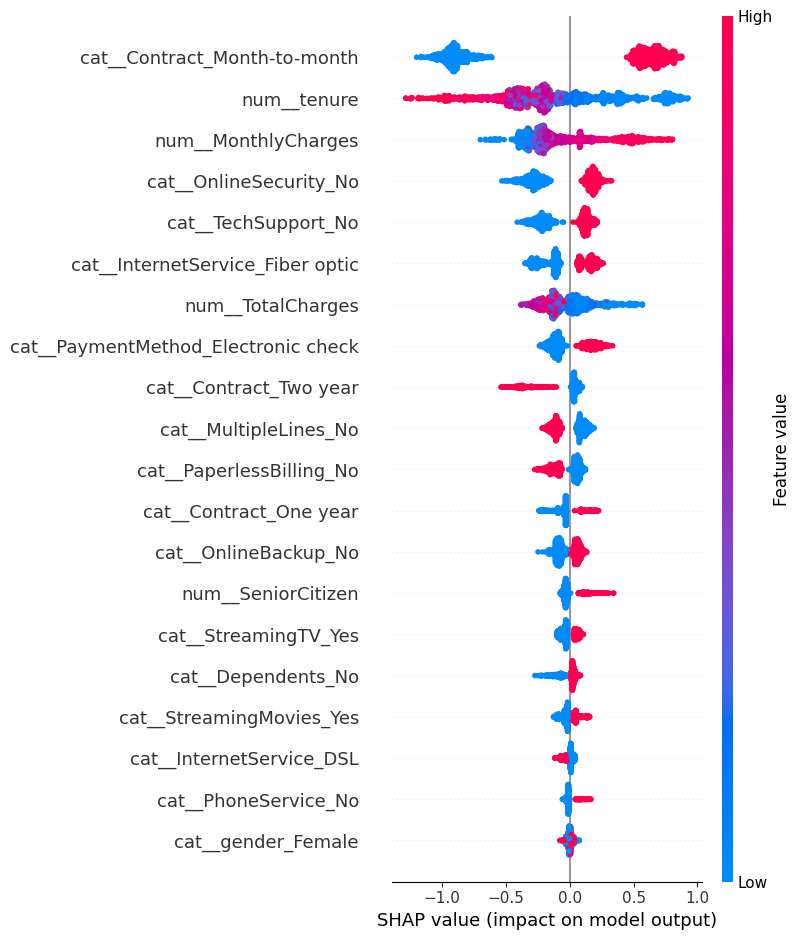

In [26]:
shap.summary_plot(
    shap_values,
    X_test_df
)

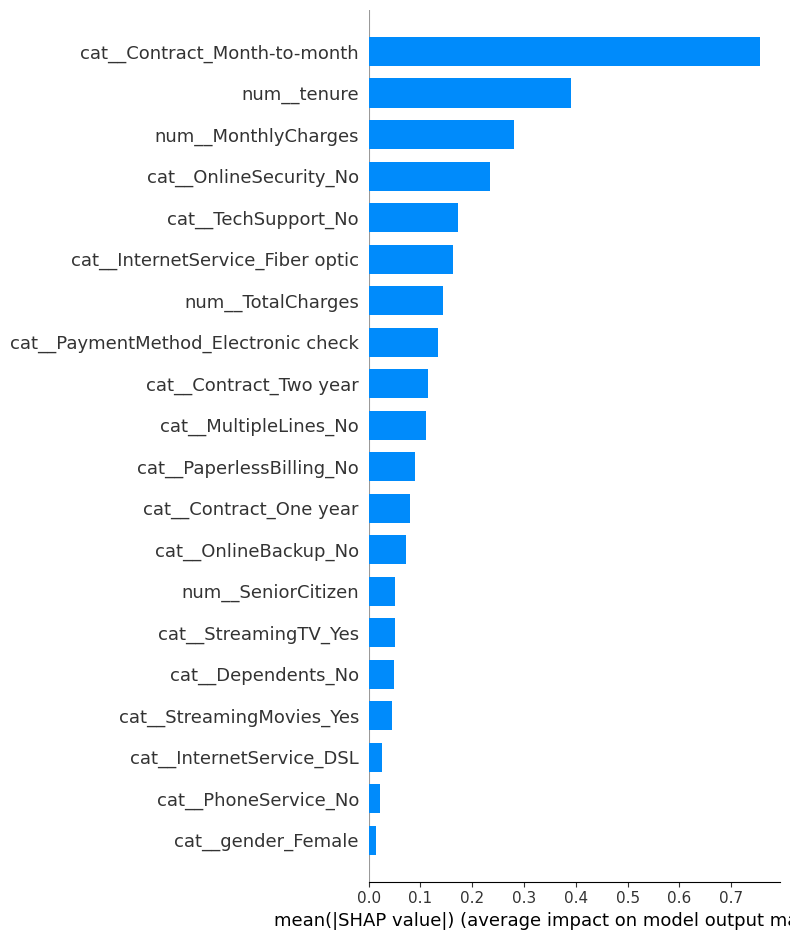

In [27]:
shap.summary_plot(
    shap_values,
    X_test_df,
    feature_names=preprocessor.get_feature_names_out(),
    plot_type="bar"
)

In [34]:

shap_values_new = explainer(X_test_df)

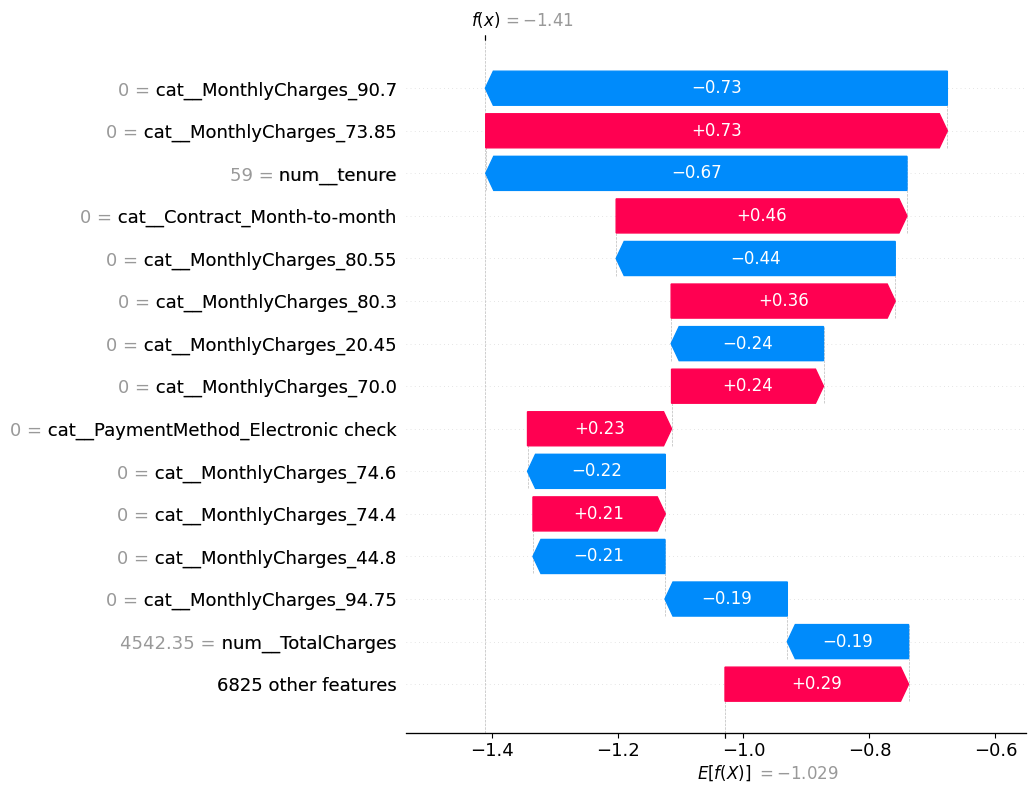

In [35]:
sample_idx = 0

shap.plots.waterfall(
    shap_values_new[sample_idx],
    max_display=15
)